<a href="https://colab.research.google.com/github/Impasbaa/BLM4504/blob/main/ZeroDCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!wget -q https://huggingface.co/datasets/geekyrakshit/LoL-Dataset/resolve/main/lol_dataset.zip
!unzip -q lol_dataset.zip -d ./

replace ./lol_dataset/eval15/high/748.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [9]:
import tensorflow as tf
from glob import glob

# Sadece "karanlık (low)" görsellerin dosya yolu
train_low_light_images = sorted(glob("./lol_dataset/our485/low/*"))
val_low_light_images = sorted(glob("./lol_dataset/eval15/low/*"))

def load_data(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    # Zero-DCE modeli, görselleri 256x256 piksel çözünürlükte işler
    image = tf.image.resize(image, size=[256, 256])
    # Piksel değerlerini (0-255) normalize ederek 0 ile 1 arasına çekiyoruz
    image = image / 255.0
    return image

def data_generator(low_light_images, batch_size=16):
    dataset = tf.data.Dataset.from_tensor_slices((low_light_images))
    dataset = dataset.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    return dataset

# 4. Eğitim ve Test verileri
train_dataset = data_generator(train_low_light_images)
val_dataset = data_generator(val_low_light_images)

print("Eğitim Verisi (Train Dataset):", train_dataset)

Eğitim Verisi (Train Dataset): <_BatchDataset element_spec=TensorSpec(shape=(16, 256, 256, 3), dtype=tf.float32, name=None)>


In [10]:
from tensorflow.keras import layers, Model

def build_dce_net():
    # Farklı çözünürlüklerdeki fotoğrafların da çalışabilmesi için
    # görüntü boyutlarını esnek (None, None) bırakıyoruz
    input_img = layers.Input(shape=(None, None, 3))

    conv1 = layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu')(input_img)
    conv2 = layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu')(conv1)
    conv3 = layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu')(conv2)
    conv4 = layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu')(conv3)

    int_con1 = layers.Concatenate(axis=-1)([conv4, conv3])
    conv5 = layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu')(int_con1)

    int_con2 = layers.Concatenate(axis=-1)([conv5, conv2])
    conv6 = layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='relu')(int_con2)

    int_con3 = layers.Concatenate(axis=-1)([conv6, conv1])

    # Tanh aktivasyonu: katsayılar -1 ile 1 arasında olacak
    # 24 kanal = 3 (RGB) x 8 (Eğri iterasyon sayısı)
    x_r = layers.Conv2D(24, (3, 3), strides=(1, 1), padding='same', activation='tanh')(int_con3)

    return Model(inputs=input_img, outputs=x_r, name="DCE-Net")

dce_model = build_dce_net()
dce_model.summary()

Model: "DCE-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │        896 │ input_layer_1[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │      9,248 │ conv2d_7[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, None,      │      9,248 │ conv2d_8[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, None,      │      9,248 │ conv2d_9[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, None,      │          0 │ conv2d_10[0][0],  │
│ (Concatenate)       │ None, 64)         │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, None,      │     18,464 │ concatenate_3[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, None,      │          0 │ conv2d_11[0][0],  │
│ (Concatenate)       │ None, 64)         │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, None,      │     18,464 │ concatenate_4[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ conv2d_12[0][0],  │
│ (Concatenate)       │ None, 64)         │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, None,      │     13,848 │ concatenate_5[0]… │
│                     │ None, 24)         │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 79,416 (310.22 KB)

 Trainable params: 79,416 (310.22 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
import tensorflow as tf

# 1.Renk Sabitliği Kaybı (Color Constancy Loss)
# Görüntüdeki renk sapmalarını (aşırı kırmızı veya mavi tonları) engeller
def color_constancy_loss(x):
    mean_rgb = tf.reduce_mean(x, axis=(1, 2), keepdims=True)
    mean_r, mean_g, mean_b = tf.split(mean_rgb, 3, axis=-1)
    diff_rg = tf.square(mean_r - mean_g)
    diff_rb = tf.square(mean_r - mean_b)
    diff_gb = tf.square(mean_b - mean_g)
    return tf.reduce_mean(tf.sqrt(tf.square(diff_rg) + tf.square(diff_rb) + tf.square(diff_gb)))

# 2.Pozlama Kontrolü Kaybı (Exposure Control Loss)
# Görüntünün ne aşırı parlak ne de çok karanlık olmasını sağlar. Ortalama pozlamayı 0.6'ya çeker
def exposure_loss(x, mean_val=0.45):
    x = tf.reduce_mean(x, axis=-1, keepdims=True)
    mean = tf.nn.avg_pool2d(x, ksize=16, strides=16, padding="VALID")
    return tf.reduce_mean(tf.square(mean - mean_val))

# 3.Aydınlatma Pürüzsüzlüğü Kaybı (Illumination Smoothness Loss)
# Komşu pikseller arasındaki aydınlatma farkının yumuşak ve doğal olmasını sağlar
def illumination_smoothness_loss(x):
    batch_size = tf.shape(x)[0]
    h_x = tf.shape(x)[1]
    w_x = tf.shape(x)[2]
    count_h = (tf.shape(x)[2] - 1) * tf.shape(x)[3]
    count_w = tf.shape(x)[2] * (tf.shape(x)[3] - 1)
    h_tv = tf.reduce_sum(tf.square((x[:, 1:, :, :] - x[:, :h_x - 1, :, :])))
    w_tv = tf.reduce_sum(tf.square((x[:, :, 1:, :] - x[:, :, :w_x - 1, :])))
    batch_size = tf.cast(batch_size, dtype=tf.float32)
    count_h = tf.cast(count_h, dtype=tf.float32)
    count_w = tf.cast(count_w, dtype=tf.float32)
    return 2 * (h_tv / count_h + w_tv / count_w) / batch_size

# 4.Mekansal Tutarlılık Kaybı (Spatial Consistency Loss)
# Aydınlatma sonrası nesnelerin kenarlarının ve dokularının bozulmasını önler
class SpatialConsistencyLoss(tf.keras.losses.Loss):
    def __init__(self, **kwargs):
        super(SpatialConsistencyLoss, self).__init__(reduction="none")
        self.left_kernel = tf.constant([[[[0, 0, 0]], [[-1, 1, 0]], [[0, 0, 0]]]], dtype=tf.float32)
        self.right_kernel = tf.constant([[[[0, 0, 0]], [[0, 1, -1]], [[0, 0, 0]]]], dtype=tf.float32)
        self.up_kernel = tf.constant([[[[0, -1, 0]], [[0, 1, 0]], [[0, 0, 0]]]], dtype=tf.float32)
        self.down_kernel = tf.constant([[[[0, 0, 0]], [[0, 1, 0]], [[0, -1, 0]]]], dtype=tf.float32)

    def call(self, y_true, y_pred):
        original_mean = tf.reduce_mean(y_true, 3, keepdims=True)
        enhanced_mean = tf.reduce_mean(y_pred, 3, keepdims=True)
        original_pool = tf.nn.avg_pool2d(original_mean, ksize=4, strides=4, padding="VALID")
        enhanced_pool = tf.nn.avg_pool2d(enhanced_mean, ksize=4, strides=4, padding="VALID")

        d_original_left = tf.nn.conv2d(original_pool, self.left_kernel, strides=[1, 1, 1, 1], padding="SAME")
        d_original_right = tf.nn.conv2d(original_pool, self.right_kernel, strides=[1, 1, 1, 1], padding="SAME")
        d_original_up = tf.nn.conv2d(original_pool, self.up_kernel, strides=[1, 1, 1, 1], padding="SAME")
        d_original_down = tf.nn.conv2d(original_pool, self.down_kernel, strides=[1, 1, 1, 1], padding="SAME")

        d_enhanced_left = tf.nn.conv2d(enhanced_pool, self.left_kernel, strides=[1, 1, 1, 1], padding="SAME")
        d_enhanced_right = tf.nn.conv2d(enhanced_pool, self.right_kernel, strides=[1, 1, 1, 1], padding="SAME")
        d_enhanced_up = tf.nn.conv2d(enhanced_pool, self.up_kernel, strides=[1, 1, 1, 1], padding="SAME")
        d_enhanced_down = tf.nn.conv2d(enhanced_pool, self.down_kernel, strides=[1, 1, 1, 1], padding="SAME")

        left_loss = tf.square(d_original_left - d_enhanced_left)
        right_loss = tf.square(d_original_right - d_enhanced_right)
        up_loss = tf.square(d_original_up - d_enhanced_up)
        down_loss = tf.square(d_original_down - d_enhanced_down)
        return tf.reduce_mean(left_loss + right_loss + up_loss + down_loss)

class ZeroDCE(tf.keras.Model):
    def __init__(self, model, **kwargs):
        super(ZeroDCE, self).__init__(**kwargs)
        self.dce_model = model

    def compile(self, learning_rate, **kwargs):
        super(ZeroDCE, self).compile(**kwargs)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        self.spatial_constancy_loss = SpatialConsistencyLoss(reduction="none")

        self.weight_spa = tf.cast(10.0, dtype=tf.float32) # Mekansal koruma
        self.weight_exp = tf.cast(5.0, dtype=tf.float32) # Aydınlatma gücü
        self.weight_col = tf.cast(15.0, dtype=tf.float32) # Renk sabitliği
        self.weight_tv = tf.cast(200.0, dtype=tf.float32) # Pürüzsüzlük

    def get_enhanced_image(self, data, output):
        # I(x) + Alpha * I(x) * (1 - I(x)) formülünün 8 kez (iteratif) uygulanması
        x = data
        for i in range(0, 24, 3):
            alpha = output[:, :, :, i:i+3]
            x = x + alpha * x * (1.0 - x)
        return x

    def train_step(self, data):
        with tf.GradientTape() as tape:
            alpha_maps = self.dce_model(data)

            enhanced_image = self.get_enhanced_image(data, alpha_maps)

            loss_spa = tf.reduce_mean(self.spatial_constancy_loss(data, enhanced_image))
            loss_exp = tf.reduce_mean(exposure_loss(enhanced_image))
            loss_col = tf.reduce_mean(color_constancy_loss(enhanced_image))
            loss_tv = tf.reduce_mean(illumination_smoothness_loss(alpha_maps))

            total_loss = (self.weight_spa * loss_spa +
                          self.weight_exp * loss_exp +
                          self.weight_col * loss_col +
                          self.weight_tv * loss_tv)

        # Geri Yayılım (Backpropagation) ve Optimizasyon
        gradients = tape.gradient(total_loss, self.dce_model.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.dce_model.trainable_weights))

        return {
            "total_loss": total_loss,
            "illumination_smoothness_loss": loss_tv,
            "spatial_constancy_loss": loss_spa,
            "color_constancy_loss": loss_col,
            "exposure_loss": loss_exp
        }

zero_dce_model = ZeroDCE(dce_model)
zero_dce_model.compile(learning_rate=1e-4)
print("Özel Kayıp Fonksiyonları ve Eğitim Döngüsü Başarıyla Kuruldu.")

Özel Kayıp Fonksiyonları ve Eğitim Döngüsü Başarıyla Kuruldu.


In [18]:
print("Model Eğitimi Başlıyor...")
history = zero_dce_model.fit(train_dataset, epochs=10)

Model Eğitimi Başlıyor...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - color_constancy_loss: 0.0013 - exposure_loss: 0.0891 - illumination_smoothness_loss: 5.0414e-04 - spatial_constancy_loss: 0.0529 - total_loss: 1.0951
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - color_constancy_loss: 7.2460e-04 - exposure_loss: 0.1042 - illumination_smoothness_loss: 1.6990e-04 - spatial_constancy_loss: 0.0269 - total_loss: 0.8351
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - color_constancy_loss: 5.2427e-04 - exposure_loss: 0.1126 - illumination_smoothness_loss: 8.2677e-05 - spatial_constancy_loss: 0.0180 - total_loss: 0.7670
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - color_constancy_loss: 4.3529e-04 - exposure_loss: 0.1178 - illumination_smoothness_loss: 4.9549e-05 - spatial_constancy_loss: 0.0136 - total_loss: 0.7417
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - color_constancy_loss: 3.8720e-04 - exposure_loss: 0.1212 - illumination_smoothness_loss: 3.

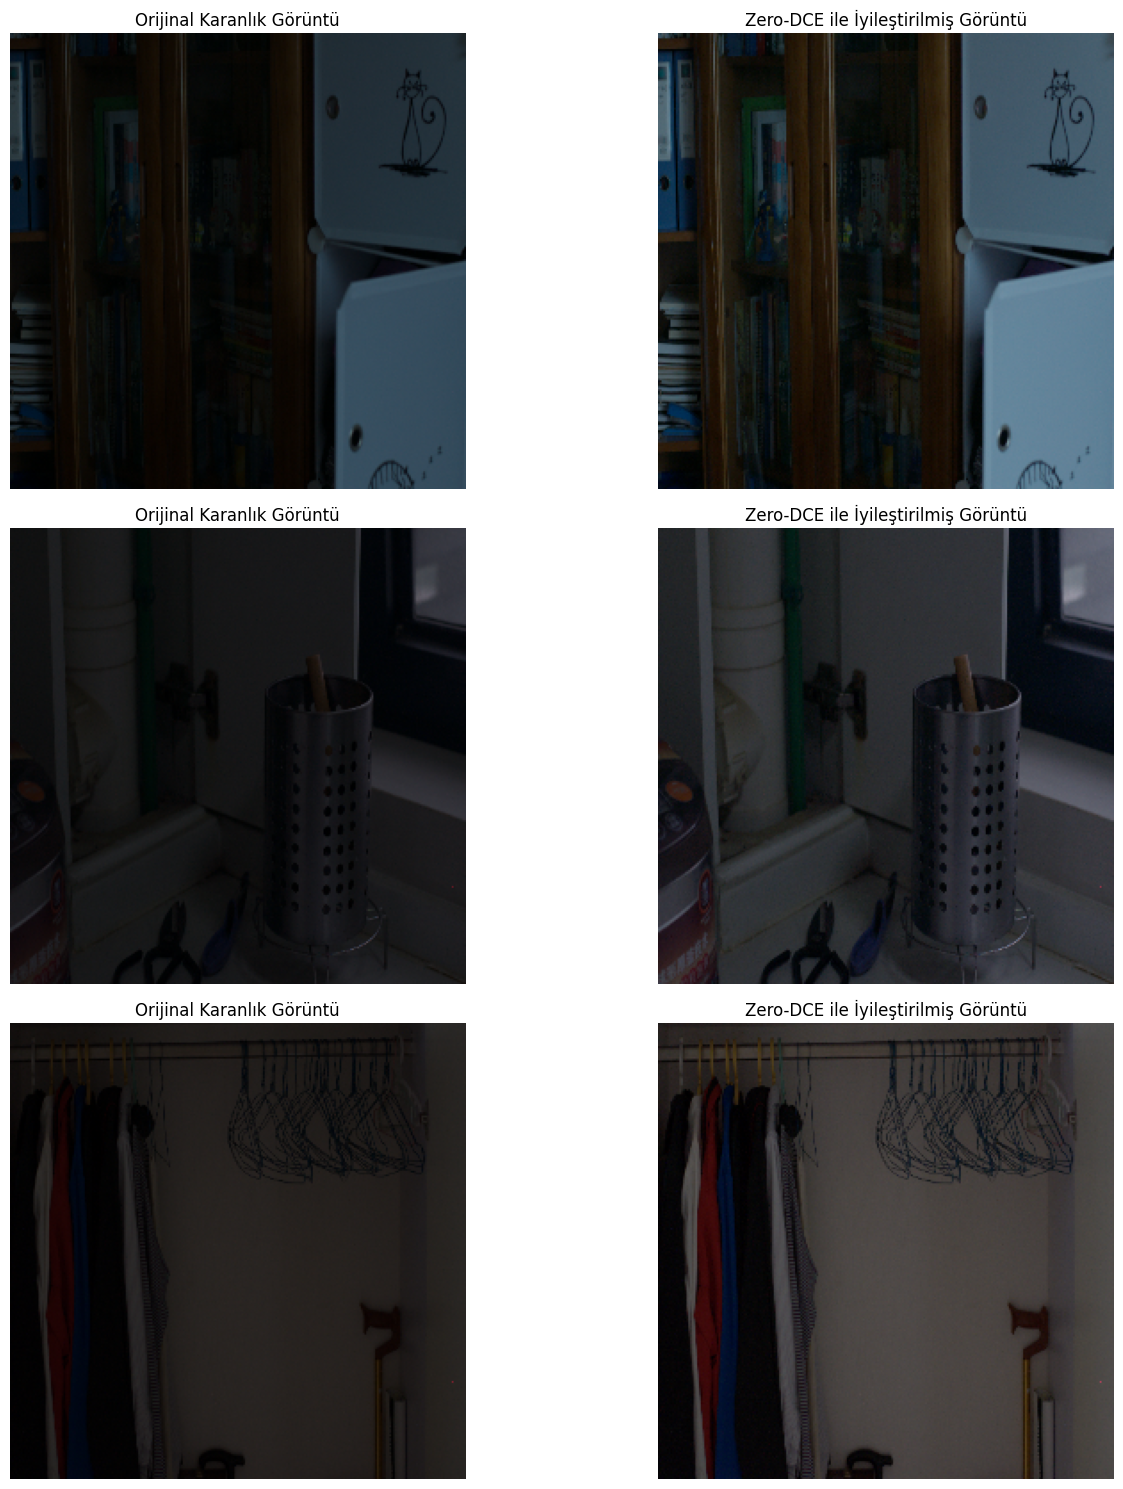

In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def plot_results(model, dataset, num_samples=3):
    plt.figure(figsize=(15, 5 * num_samples))

    for i, image_batch in enumerate(dataset.take(1)):
        for j in range(num_samples):
            original_image = image_batch[j:j+1]

            # Modelin tahmin ettiği aydınlatma katsayıları
            alpha_maps = model.dce_model(original_image)

            enhanced_image = model.get_enhanced_image(original_image, alpha_maps)

            original_img_np = np.squeeze(original_image.numpy())
            enhanced_img_np = np.squeeze(enhanced_image.numpy())

            plt.subplot(num_samples, 2, 2*j + 1)
            plt.imshow(original_img_np)
            plt.title("Orijinal Karanlık Görüntü")
            plt.axis("off")

            plt.subplot(num_samples, 2, 2*j + 2)
            plt.imshow(enhanced_img_np)
            plt.title("Zero-DCE ile İyileştirilmiş Görüntü")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_results(zero_dce_model, val_dataset)

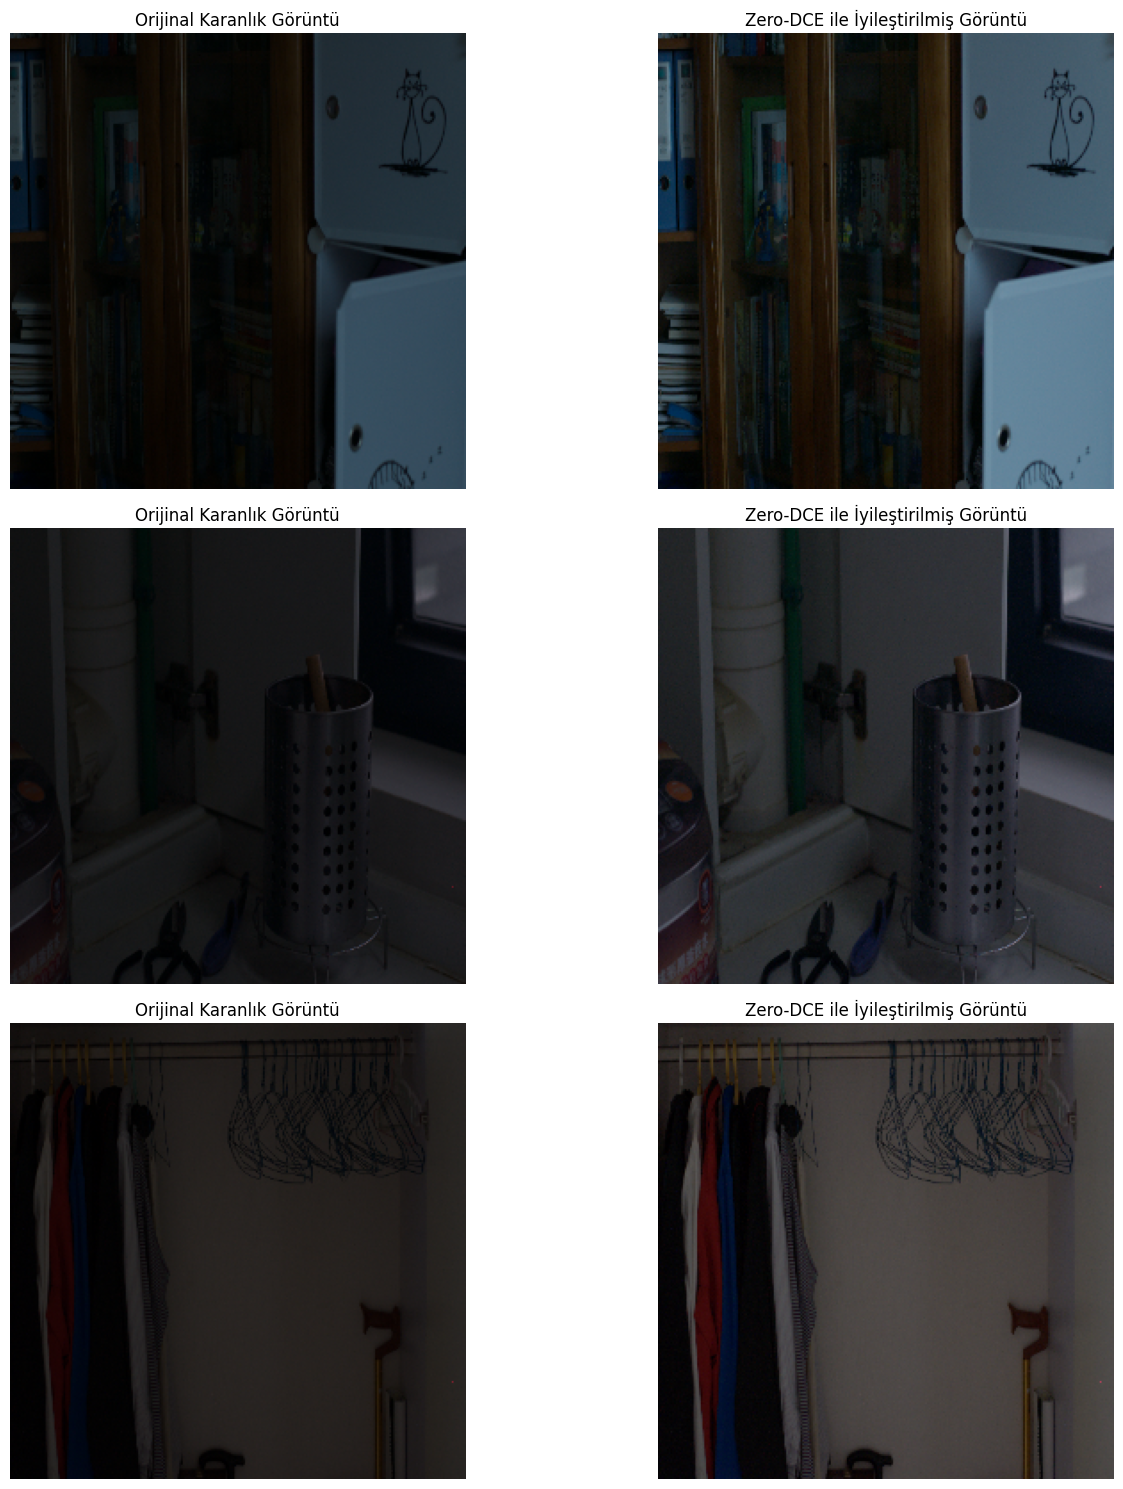

In [20]:
val_dataset = tf.data.Dataset.from_tensor_slices((val_low_light_images))
val_dataset = val_dataset.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(15, drop_remainder=False)

plot_results(zero_dce_model, val_dataset, num_samples=3)

In [22]:
import os
import tensorflow as tf

zero_dce_model = ZeroDCE(dce_model)
zero_dce_model.compile(learning_rate=1e-4)

dce_model.build(tf.TensorShape([None, 256, 256, 3]))
zero_dce_model.build(tf.TensorShape([None, 256, 256, 3]))

dce_model.load_weights("/zero_dce_200_epochs.weights.h5")
print("Eski ağırlıklar başarıyla yüklendi! Model sıfırdan değil, 100. epoch seviyesinden başlıyor.")

os.makedirs("saved_models", exist_ok=True)
checkpoint_filepath = "saved_models/zero_dce_200_epochs.weights.h5"

class InnerModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath):
        super(InnerModelCheckpoint, self).__init__()
        self.filepath = filepath
        self.best_loss = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('total_loss')
        if current_loss is not None and current_loss < self.best_loss:
            print(f"\nEpoch {epoch + 1}: total_loss düştü ({self.best_loss:.5f} -> {current_loss:.5f}). Ağırlıklar kaydediliyor...")
            self.best_loss = current_loss
            self.model.dce_model.save_weights(self.filepath)

custom_checkpoint = InnerModelCheckpoint(filepath=checkpoint_filepath)

print("Ek 100 Epoch'luk Eğitim Başlıyor...")
history_long = zero_dce_model.fit(
    train_dataset,
    epochs=100,
    callbacks=[custom_checkpoint]
)

Eski ağırlıklar başarıyla yüklendi! Model sıfırdan değil, 100. epoch seviyesinden başlıyor.
Ek 100 Epoch'luk Eğitim Başlıyor...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - color_constancy_loss: 0.0090 - exposure_loss: 0.0574 - illumination_smoothness_loss: 6.7301e-04 - spatial_constancy_loss: 0.1253 - total_loss: 1.8093
Epoch 1: total_loss düştü (inf -> 1.08637). Ağırlıklar kaydediliyor...
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - color_constancy_loss: 0.0013 - exposure_loss: 0.0894 - illumination_smoothness_loss: 4.9642e-04 - spatial_constancy_loss: 0.0520 - total_loss: 1.0864
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - color_constancy_loss: 0.0040 - exposure_loss: 0.0831 - illumination_smoothness_loss: 2.4817e-04 - spatial_constancy_loss: 0.0390 - total_loss: 0.9152
Epoch 2: total_loss düştü (1.08637 -> 0.82962). Ağırlıklar kaydediliyor...
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - color_constancy_loss: 7.1063e-04 - exposure_loss: 0.1048 - illumination_smoothn